<a href="https://colab.research.google.com/github/Bassana07/Formation_REESO/blob/main/TP%20integration%20Theme%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP-02 : Analyse des déplacements forcés de population

# Partie A : Import et exploration

In [2]:
# 1. Importons le fichier event_data_bfa.csv
import pandas as pd
import numpy as np
import gdown
from google.colab import files

url = "https://drive.google.com/uc?id=1RqzkRROMKwYOUz773GDsY7iBXQzsCK-v"
output = "event_data_bfa.csv"

# telechargeons le fichier depuis le drive
gdown.download(url, output, quiet=False)

# 2. Affichons les 15 premières lignes

df = pd.read_csv(output)
pd.set_option('display.max_columns', None)
df.head(15)

Downloading...
From: https://drive.google.com/uc?id=1RqzkRROMKwYOUz773GDsY7iBXQzsCK-v
To: /content/event_data_bfa.csv
100%|██████████| 26.2k/26.2k [00:00<00:00, 53.5MB/s]


,id,country,iso3,latitude,longitude,centroid,role,displacement_type,qualifier,figure,displacement_date,displacement_start_date,displacement_end_date,year,event_id,event_name,event_codes,event_code_types,event_start_date,event_end_date,category,subcategory,type,subtype,old_id,sources,source_url,locations_name,locations_coordinates,locations_accuracy,locations_type,displacement_occurred,created_at,description,link,combined_type
0,240788,Burkina Faso,BFA,13.123900,-4.158790,"[13.1239, -4.15879]",Recommended figure,Conflict,total,1536,2026-02-06,2026-02-05,2026-02-06,2026,40365,Burkina Faso: Non-International armed conflict...,747_260205_KOODJI,Local Identifier,2026-02-05,2026-02-05,NaN,NaN,NaN,NaN,NaN,Action Sociale,NaN,"Djibasso, Kossi, Boucle du Mouhoun, Burkina Faso","13.1239, -4.15879",County/City/town/Village/Woreda (ADM3),Origin and destination,Displacement without preventive evacuations re...,2026-02-24T08:10:05.559962Z,"Burkina Faso: 1,536 displacements, 05 February...",NaN,Conflict
1,226297,Burkina Faso,BFA,12.913285,-2.603698,"[12.9132847, -2.6036978]",Recommended figure,Conflict,total,2380,2026-02-03,2026-01-29,2026-02-03,2026,39332,Burkina Faso: Non-International armed conflict...,746_260129_PASBAG,Local Identifier,2026-01-29,2026-01-29,NaN,NaN,NaN,NaN,NaN,Action Sociale,NaN,"Bagaré, Passoré, North, Burkina Faso","12.9132847, -2.6036978",County/City/town/Village/Woreda (ADM3),Origin and destination,Displacement without preventive evacuations re...,2026-02-06T11:57:14.305819Z,"Burkina Faso: 2,380 displacements, 29 January ...",NaN,Conflict
2,226298,Burkina Faso,BFA,11.892606,-4.338064,"[11.892606, -4.338064]",Recommended figure,Conflict,total,1500,2026-01-28,2026-01-27,2026-01-28,2026,39331,Burkina Faso: Non-International armed conflict...,745_260127_BANKOU,Local Identifier,2026-01-27,2026-01-27,NaN,NaN,NaN,NaN,NaN,Action Sociale,NaN,"Kouka, Banwa, Boucle du Mouhoun, Burkina Faso","11.892606, -4.338064",County/City/town/Village/Woreda (ADM3),Origin and destination,Displacement without preventive evacuations re...,2026-02-06T11:57:14.367762Z,"Burkina Faso: 1,500 displacements, 27 January ...",NaN,Conflict
3,240790,Burkina Faso,BFA,13.123900,-4.158790,"[13.1239, -4.15879]",Recommended figure,Conflict,total,3943,2026-01-24,2026-01-22,2026-01-24,2026,40363,Burkina Faso: Non-International armed conflict...,739_260122_KOODJI,Local Identifier,2026-01-22,2026-01-22,NaN,NaN,NaN,NaN,NaN,Action Sociale,NaN,"Djibasso, Kossi, Boucle du Mouhoun, Burkina Faso","13.1239, -4.15879",County/City/town/Village/Woreda (ADM3),Origin and destination,Displacement without preventive evacuations re...,2026-02-24T08:10:05.642039Z,"Burkina Faso: 3,943 displacements, 22 January ...",NaN,Conflict
4,240786,Burkina Faso,BFA,12.910260,-2.451240,"[12.910260000000001, -2.45124]",Recommended figure,Conflict,total,1048,2026-02-13,2026-01-20,2026-02-13,2026,40367,Burkina Faso: Non-International armed conflict...,749_260120_PASYAK,Local Identifier,2026-01-20,2026-01-20,NaN,NaN,NaN,NaN,NaN,Action Sociale,NaN,"Bagaré, Passoré, North, Burkina Faso; Yako, Pa...","12.86142, -2.64173; 12.9591, -2.26075",County/City/town/Village/Woreda (ADM3); County...,Origin; Destination,Displacement without preventive evacuations re...,2026-02-24T08:10:05.465116Z,"Burkina Faso: 1,048 displacements, 20 January ...",NaN,Conflict
5,240787,Burkina Faso,BFA,12.881040,-2.549485,"[12.88104, -2.549485]",Recommended figure,Conflict,total,894,2026-02-13,2026-01-20,2026-02-13,2026,40366,Burkina Faso: Non-International armed conflict...,748_260120_PASLA-,Local Identifier,2026-01-20,2026-01-20,NaN,NaN,NaN,NaN,NaN,Action Sociale,NaN,"Bagaré, Passoré, North, Burkina Faso; La Toden...","12.86142, -2.64173; 12.90066, -2.45724",County/City/town/Village/Woreda (ADM3); County...,Origin; Destination,Displacement without preventive evacuations re...,2026-02-24T08:10:05.517628Z,"Burkina Faso: 894 displacements, 20 January - ...",NaN,Conflict
6,226299,Burkina Faso,BFA,12.913285,-2.603698,"[12.9132847, 

In [3]:
# 3. Affichons les informations du DataFrame
df.info()

# 4. Identifions les colonnes contenant des données géographiques
geo_cols = ['latitude', 'longitude', 'locations_name']
print(f"Colonnes géographiques : {geo_cols}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       25 non-null     int64  
 1   country                  25 non-null     object 
 2   iso3                     25 non-null     object 
 3   latitude                 25 non-null     float64
 4   longitude                25 non-null     float64
 5   centroid                 25 non-null     object 
 6   role                     25 non-null     object 
 7   displacement_type        25 non-null     object 
 8   qualifier                25 non-null     object 
 9   figure                   25 non-null     int64  
 10  displacement_date        25 non-null     object 
 11  displacement_start_date  25 non-null     object 
 12  displacement_end_date    25 non-null     object 
 13  year                     25 non-null     int64  
 14  event_id                 25 

In [4]:
# 5. Comptons le nombre total d'événements de déplacement
total_events = len(df)
print(f"Nombre total d'événements : {total_events}")

# 6. Calculons le nombre total de personnes déplacées (somme de figure)
total_deplaces = df['figure'].sum()
print(f"Total personnes déplacées : {total_deplaces:,}")

Nombre total d'événements : 25
Total personnes déplacées : 61,746


In [5]:
# 7. Identifions les types de déplacements uniques (colonne category)
categories = df['category'].unique()
print(f"Types uniques : {categories}")

# 8. Affichons la distribution des événements par catégorie
df['category'].value_counts()

Types uniques : [nan 'Weather related']


,count
category,
Weather related,1


# Partie B : Nettoyage et préparation

In [6]:
# 9. Convertissons les colonnes de dates en datetime
date_cols = ['displacement_date', 'displacement_start_date', 'displacement_end_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("✓ Conversion effectuée")
df[date_cols].dtypes

✓ Conversion effectuée


,0
displacement_date,datetime64[ns]
displacement_start_date,datetime64[ns]
displacement_end_date,datetime64[ns]


In [7]:
# 10. Extrayons le mois et l'année de displacement_date
df['mois'] = df['displacement_date'].dt.month
df['annee'] = df['displacement_date'].dt.year

# 11. Calculons la durée des déplacements en jours
df['duree_jours'] = (df['displacement_end_date'] - df['displacement_start_date']).dt.days

# 12. Identifions les événements avec une durée supérieure à 7 jours
longs = df[df['duree_jours'] > 7]
print(f"Événements > 7 jours : {len(longs)}")
df[['displacement_date', 'mois', 'annee', 'duree_jours']].head()

Événements > 7 jours : 10


,displacement_date,mois,annee,duree_jours
0,2026-02-06,2,2026,1
1,2026-02-03,2,2026,5
2,2026-01-28,1,2026,1
3,2026-01-24,1,2026,2
4,2026-02-13,2,2026,24


In [8]:
# 13. Vérifions les valeurs manquantes dans latitude et longitude
missing_geo = df[['latitude', 'longitude']].isna().sum()
print("Valeurs manquantes :")
print(missing_geo)

# 14. Supprimons les lignes sans coordonnées géographiques
df_clean = df.dropna(subset=['latitude', 'longitude'])
print(f"\n✓ Lignes supprimées : {len(df) - len(df_clean)}")

Valeurs manquantes :
latitude     0
longitude    0
dtype: int64

✓ Lignes supprimées : 0


In [9]:
# 15. Vérifions que les latitudes sont entre 9 et 15 (limites du Burkina Faso)
lat_valid = df_clean['latitude'].between(9, 15)
print(f"Latitudes hors limites : {(~lat_valid).sum()}")

# 16. Vérifions que les longitudes sont entre -6 et 3
lon_valid = df_clean['longitude'].between(-6, 3)
print(f"Longitudes hors limites : {(~lon_valid).sum()}")

# Filtrage final
df_geo = df_clean[lat_valid & lon_valid].copy()
print(f"\n✓ DataFrame géo valide : {len(df_geo)} lignes")

Latitudes hors limites : 0
Longitudes hors limites : 0

✓ DataFrame géo valide : 25 lignes


In [10]:
# 17 & 18. Extrayons la région depuis locations_name
# Format: "Village, Province, Région, Burkina Faso"

region_aliases = {
    'East': 'Est',
    'North': 'Nord',
    'Centre-Nord Region': 'Centre-Nord'
}

def extract_region(location):
    if pd.isna(location):
        return np.nan

    # Si deux localités sont présentes ("A; B"), on prend la dernière.
    location_text = str(location).split(';')[-1].strip()
    parts = [p.strip() for p in location_text.split(',')]

    if len(parts) >= 2:
        region = parts[-2]
        return region_aliases.get(region, region)
    return np.nan

df_geo['region'] = df_geo['locations_name'].apply(extract_region)

# 19. Comptons le nombre d'événements par région
events_par_region = df_geo['region'].value_counts()
print("Événements par région :")
events_par_region

Événements par région :


,count
region,
Boucle du Mouhoun,10
Nord,9
Est,5
Centre-Nord,1


# Partie C : Analyse avec NumPy et Pandas

Figure exportée : figures_tp02/01_deplacements_par_mois.png


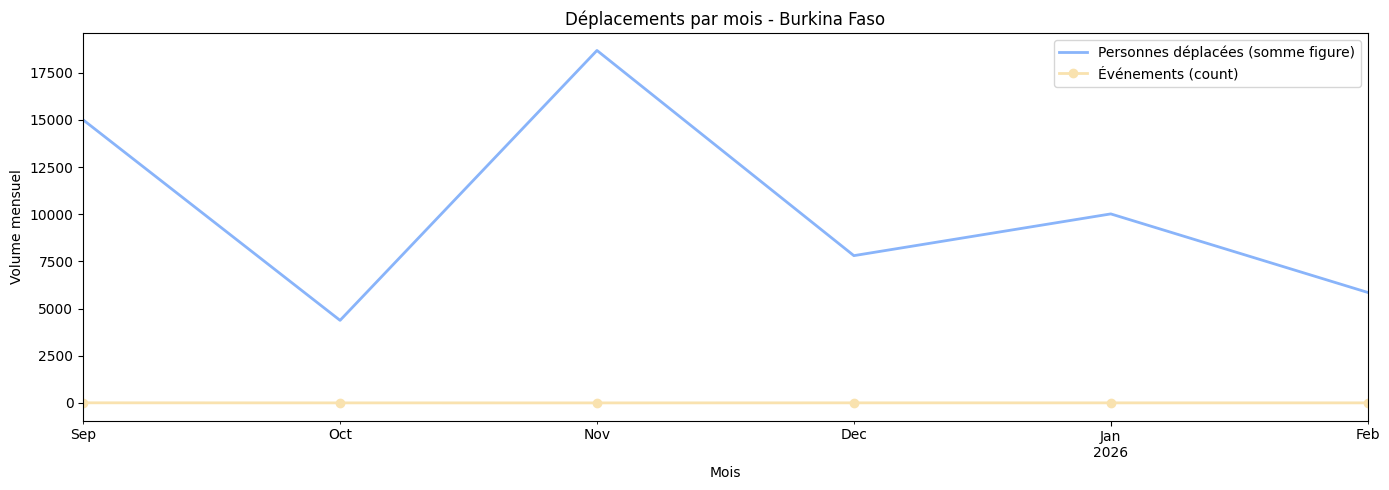

In [32]:
# 20. Graphique : déplacements par mois
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIG_DIR = 'figures_tp02'
FIG_DPI = 300
os.makedirs(FIG_DIR, exist_ok=True)


def save_current_fig(fig_name):
    path = os.path.join(FIG_DIR, fig_name)
    plt.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    print(f'Figure exportée : {path}')


# Série principale (personnes déplacées)
deplac_par_mois = df_geo.groupby(df_geo['displacement_date'].dt.to_period('M'))['figure'].sum()

# Série complémentaire (nombre d'événements)
events_par_mois = df_geo.groupby(df_geo['displacement_date'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(14, 5))
deplac_par_mois.plot(ax=ax, color='#89b4fa', linewidth=2, label='Personnes déplacées (somme figure)')
events_par_mois.plot(ax=ax, color='#f9e2af', linewidth=2, marker='o', label="Événements (count)")
ax.set_title('Déplacements par mois - Burkina Faso')
ax.set_xlabel('Mois')
ax.set_ylabel('Volume mensuel')
ax.legend()
plt.tight_layout()
save_current_fig('01_deplacements_par_mois.png')
plt.show()

In [36]:
# 21. Mois avec le plus grand nombre de déplacements
mois_max = deplac_par_mois.idxmax()
print(f"Mois avec le plus de déplacements : {mois_max} → {deplac_par_mois.max():,} déplacés")

# 22. Moyenne mobile sur 7 jours
daily = df_geo.groupby('displacement_date')['figure'].sum()
rolling_7 = daily.rolling(7).mean()
print(f"Moyenne mobile (7j) calculée sur {len(rolling_7.dropna())} points")

# 23. Périodes de pics (> percentile 90)
seuil_pic = daily.quantile(0.9)
pics = daily[daily > seuil_pic]
print(f"\nPériodes de pics (>{seuil_pic:,.0f} déplacés/jour) :")
print(pics.sort_values(ascending=False).head(5))

Mois avec le plus de déplacements : 2025-11 → 18,682 déplacés
Moyenne mobile (7j) calculée sur 12 points

Périodes de pics (>5,425 déplacés/jour) :
displacement_date
2025-11-03    18682
2025-09-30     7839
Name: figure, dtype: int64


In [13]:
# 24. Total de déplacés par région
total_par_region = df_geo.groupby('region')['figure'].sum().sort_values(ascending=False)

# 25. Top 5 régions les plus affectées
print("Top 5 régions les plus affectées :")
print(total_par_region.head(5))

# 26. Nombre moyen de déplacés par événement par région
moy_par_region = df_geo.groupby('region')['figure'].mean().round(0)

# 27. DataFrame résumé par région
resume_region = df_geo.groupby('region')['figure'].agg(
    nb_evenements='count',
    total_deplaces='sum',
    moyenne_par_evt='mean',
    min_deplaces='min',
    max_deplaces='max'
).round(1).sort_values('total_deplaces', ascending=False)
resume_region

Top 5 régions les plus affectées :
region
Boucle du Mouhoun    36783
Nord                 17695
Est                   5898
Centre-Nord           1370
Name: figure, dtype: int64


,nb_evenements,total_deplaces,moyenne_par_evt,min_deplaces,max_deplaces
region,,,,,
Boucle du Mouhoun,10,36783,3678.3,1349,9341
Nord,9,17695,1966.1,211,3894
Est,5,5898,1179.6,131,2868
Centre-Nord,1,1370,1370.0,1370,1370


In [14]:
# 28. Top 10 localités avec le plus grand nombre de déplacements
top10_localites = df_geo.groupby('locations_name')['figure'].sum().\
    sort_values(ascending=False).head(10)
print("Top 10 localités :")
print(top10_localites)

# 29. Fréquence de déplacement par localité
freq_localite = df_geo['locations_name'].value_counts()
print(f"\nLocalité la plus fréquente : {freq_localite.idxmax()} ({freq_localite.max()} événements)")

# 30. Localités avec plusieurs vagues (> 2 événements)
multi_vagues = freq_localite[freq_localite > 2]
print(f"Localités avec plusieurs vagues : {len(multi_vagues)}")

# 31. Hotspots : > 1000 déplacés ET > 2 événements
stats_loc = df_geo.groupby('locations_name')['figure'].agg(['sum', 'count'])
hotspots = stats_loc[(stats_loc['sum'] > 1000) & (stats_loc['count'] > 2)]
print(f"\nHotspots identifiés : {len(hotspots)}")
hotspots.sort_values('sum', ascending=False).head(5)

Top 10 localités :
locations_name
Djibasso, Kossi, Boucle du Mouhoun, Burkina Faso                                                  32643
Gomboro, Sourou, Boucle du Mouhoun, Burkina Faso; Zogoré, Yatenga, North, Burkina Faso             7839
Bagaré, Passoré, North, Burkina Faso                                                               4907
Piéla, Gnagna Province, Est, Burkina Faso                                                          2868
Gomboro, Sourou, Boucle du Mouhoun, Burkina Faso; Ouahigouya, Yatenga, North, Burkina Faso         2796
Kouka, Banwa, Boucle du Mouhoun, Burkina Faso; Solenzo, Banwa, Boucle du Mouhoun, Burkina Faso     2640
Bilanga, Gnagna, East, Burkina Faso; Piéla, Gnagna Province, Est, Burkina Faso                     1523
Kouka, Banwa, Boucle du Mouhoun, Burkina Faso                                                      1500
Boala, Namentenga, Centre-Nord Region, Burkina Faso                                                1370
Bagaré, Passoré, North, Burkin

,sum,count
locations_name,,
"Djibasso, Kossi, Boucle du Mouhoun, Burkina Faso",32643,8
"Gomboro, Sourou, Boucle du Mouhoun, Burkina Faso; Zogoré, Yatenga, North, Burkina Faso",7839,3


In [15]:
# 32. Convertissons la figure en array NumPy
figures_array = df_geo['figure'].to_numpy()
print(f"Array shape : {figures_array.shape}, dtype : {figures_array.dtype}")

# 33. Médiane, percentile 75 et 90
mediane  = np.median(figures_array)
p75      = np.percentile(figures_array, 75)
p90      = np.percentile(figures_array, 90)
print(f"Médiane   : {mediane:,.0f}")
print(f"P75       : {p75:,.0f}")
print(f"P90       : {p90:,.0f}")

# 34. Déplacements massifs (> 90e percentile)
massifs = df_geo[df_geo['figure'] > p90]
print(f"\nDéplacements massifs : {len(massifs)} événements")

# 35. Écart-type et coefficient de variation
ecart_type = np.std(figures_array)
cv         = (ecart_type / np.mean(figures_array)) * 100
print(f"Écart-type : {ecart_type:,.1f}")
print(f"CV         : {cv:.1f}%")

Array shape : (25,), dtype : int64
Médiane   : 1,536
P75       : 2,868
P90       : 3,923

Déplacements massifs : 3 événements
Écart-type : 2,290.6
CV         : 92.7%


# Partie D : Visualisations

Figure exportée : figures_tp02/02_evolution_quotidienne_deplacements.png


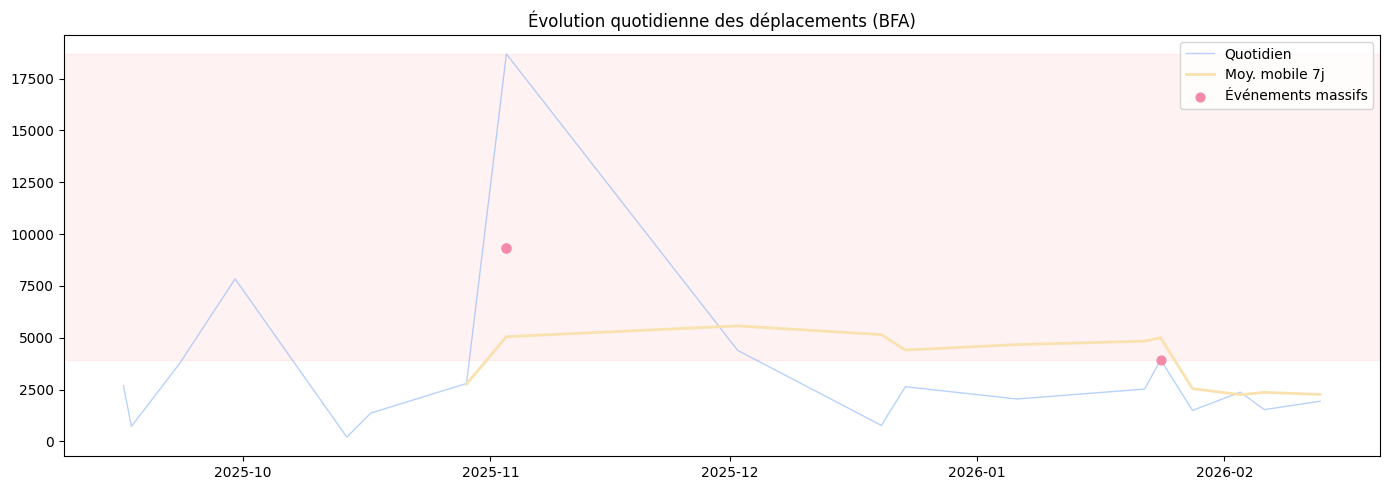

In [16]:
# 36-39. Évolution temporelle avec marqueurs et couleurs par intensité
fig, ax = plt.subplots(figsize=(14, 5))

# 36. Ligne d'évolution quotidienne
ax.plot(daily.index, daily.values, color='#89b4fa', alpha=0.6, lw=1, label='Quotidien')
ax.plot(rolling_7.index, rolling_7.values, color='#f9e2af', lw=2, label='Moy. mobile 7j')

# 37. Marqueurs pour événements massifs
ax.scatter(massifs['displacement_date'], massifs['figure'],
           color='#f38ba8', s=40, zorder=5, label='Événements massifs')

# 39. Couleur de fond selon intensité
ax.axhspan(p90, daily.max(), alpha=0.05, color='red')
ax.legend()
ax.set_title('Évolution quotidienne des déplacements (BFA)')
plt.tight_layout()
save_current_fig('02_evolution_quotidienne_deplacements.png')
plt.show()

Figure exportée : figures_tp02/03_top10_regions_barplot.png


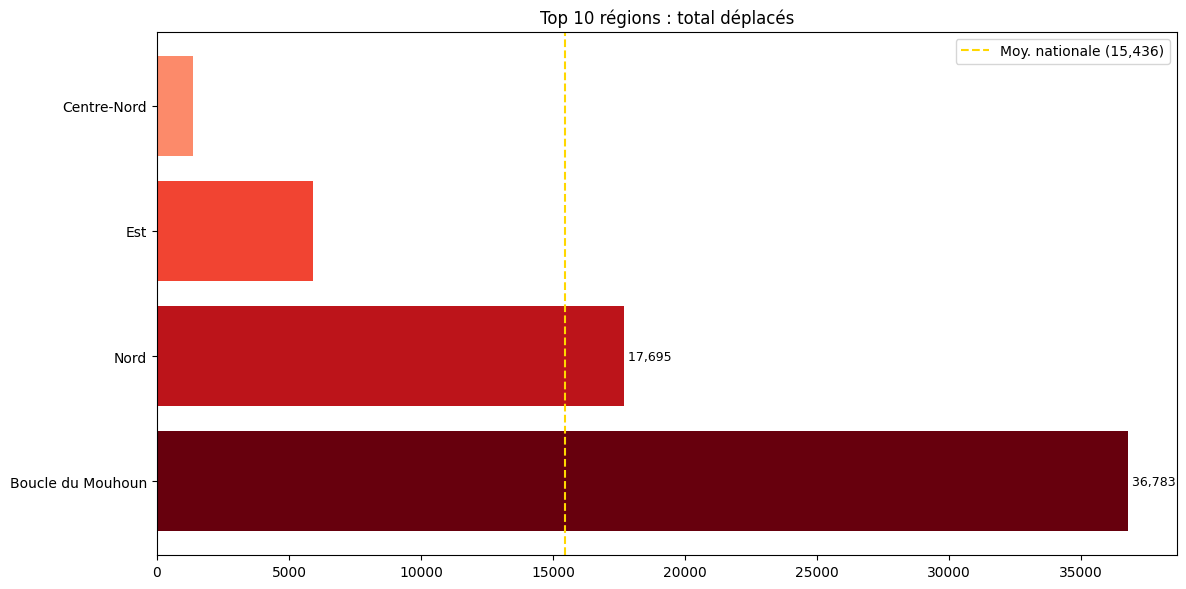

In [17]:
# 40-43. Barplot Top 10 régions + annotations
top10_reg = total_par_region.head(10)
moyenne_nat = total_par_region.mean()

fig, ax = plt.subplots(figsize=(12, 6))

# 41. Palette "Reds"
colors = plt.cm.Reds(np.linspace(0.4, 1.0, len(top10_reg)))
bars = ax.barh(top10_reg.index, top10_reg.values, color=colors[::-1])

# 42. Ligne horizontale : moyenne nationale
ax.axvline(moyenne_nat, color='gold', ls='--', lw=1.5, label=f'Moy. nationale ({moyenne_nat:,.0f})')

# 43. Annoter les régions > 10 000 déplacés
for bar, (reg, val) in zip(bars, top10_reg.items()):
    if val > 10000:
        ax.text(val, bar.get_y() + bar.get_height()/2,
                f' {val:,.0f}', va='center', fontsize=9)
ax.legend()
ax.set_title('Top 10 régions : total déplacés')
plt.tight_layout()
save_current_fig('03_top10_regions_barplot.png')
plt.show()

Figure exportée : figures_tp02/04_heatmap_region_mois.png


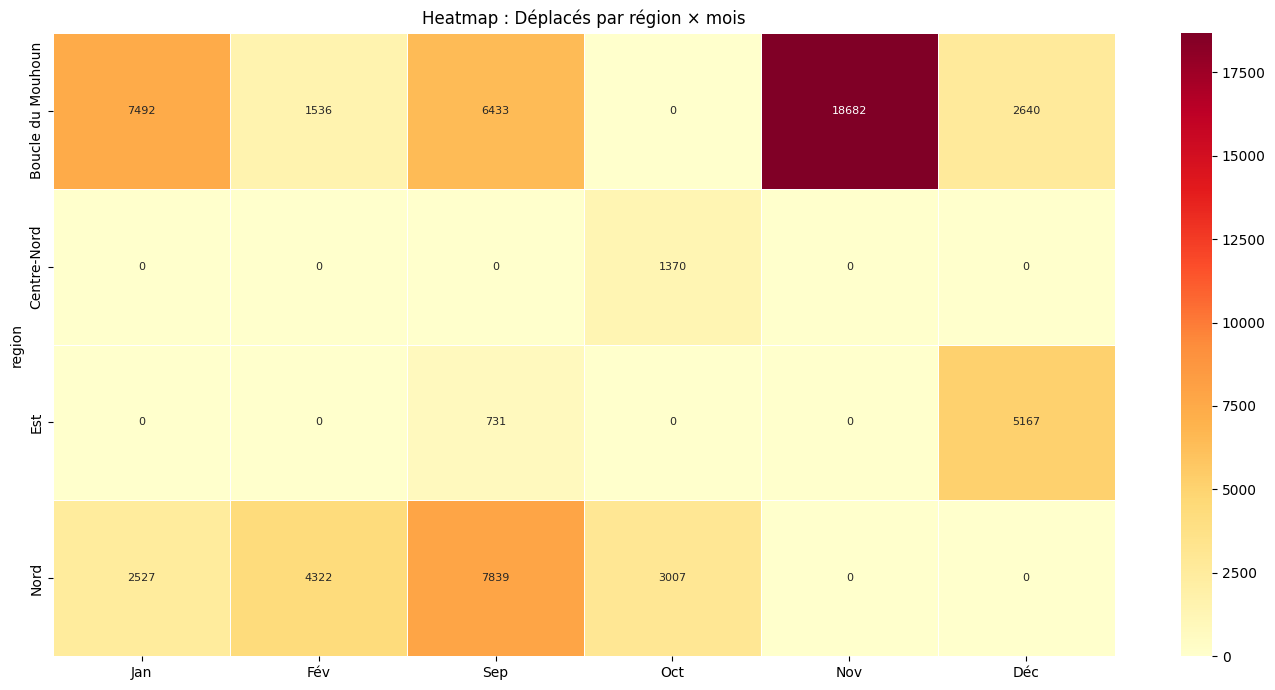

In [18]:
# 44-46. Tableau croisé mois × région + heatmap seaborn
import seaborn as sns

# 44. Tableau croisé
pivot = df_geo.pivot_table(
    values='figure',
    index='region',
    columns=df_geo['displacement_date'].dt.month,
    aggfunc='sum',
    fill_value=0
)

# Renommage sûr : mapping num → abréviation
mois_map = {1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
            7:'Jul', 8:'Aoû', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Déc'}
pivot.columns = [mois_map[m] for m in pivot.columns]

# 45. Heatmap
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.0f',
            linewidths=0.5, annot=True, annot_kws={'size': 8})
ax.set_title('Heatmap : Déplacés par région × mois')
plt.tight_layout()
save_current_fig('04_heatmap_region_mois.png')
plt.show()

Figure exportée : figures_tp02/05_scatter_geo_deplacements.png


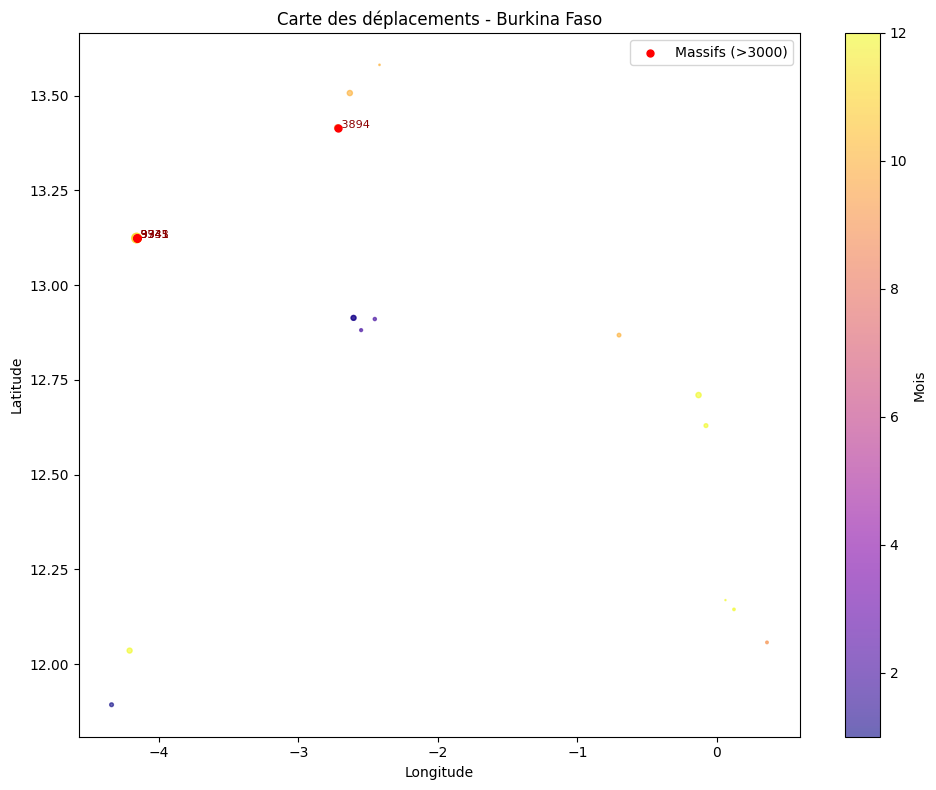

In [19]:
# 47-50. Scatter plot géographique
fig, ax = plt.subplots(figsize=(10, 8))

# 47-49. longitude X, latitude Y, taille=figure, couleur=mois
sc = ax.scatter(
    df_geo['longitude'],
    df_geo['latitude'],
    s=df_geo['figure'] / 200,
    c=df_geo['mois'],
    cmap='plasma',
    alpha=0.6
)
plt.colorbar(sc, ax=ax, label='Mois')

# 50. Annotons les événements massifs (figure > 3000)
massifs_geo = df_geo[df_geo['figure'] > 3000]
ax.scatter(massifs_geo['longitude'], massifs_geo['latitude'],
           s=25, color='red', zorder=5, label='Massifs (>3000)')
for _, row in massifs_geo.iterrows():
    ax.text(row['longitude'], row['latitude'],
            f" {int(row['figure'])}", fontsize=8, color='darkred')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Carte des déplacements - Burkina Faso')
ax.legend()
plt.tight_layout()
save_current_fig('05_scatter_geo_deplacements.png')
plt.show()

Figure exportée : figures_tp02/06_analyse_complete_4panel.png
✓ Figure sauvegardée (300 dpi)


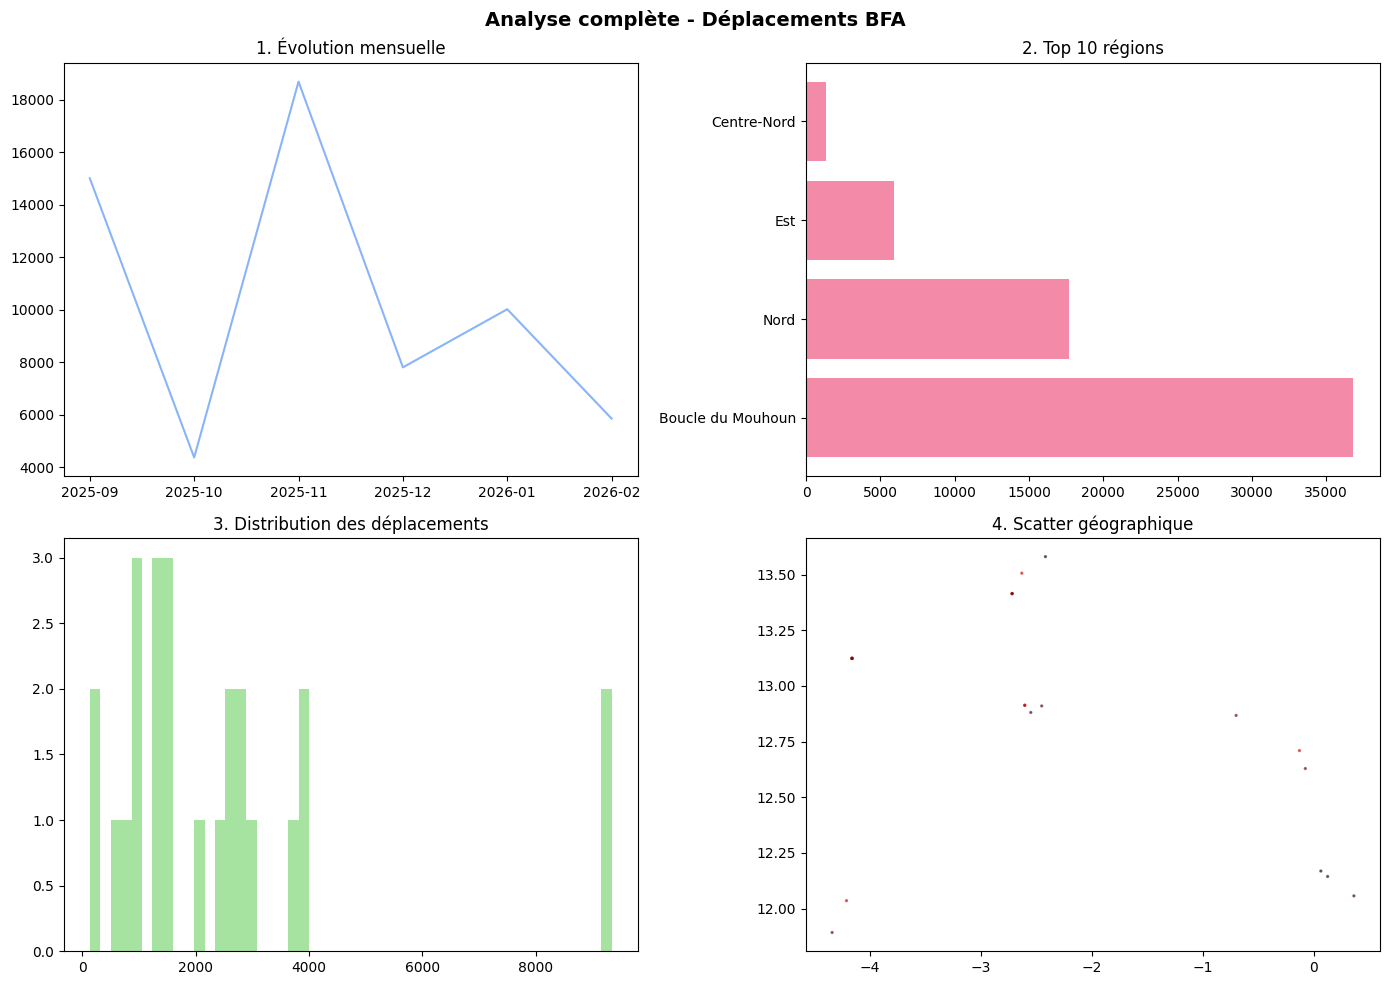

In [20]:
# 51-53. Subplot 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse complète - Déplacements BFA', fontsize=14, fontweight='bold')

# Subplot 1 : Évolution temporelle (ligne)
axes[0,0].plot(deplac_par_mois.index.astype(str), deplac_par_mois.values, color='#89b4fa')
axes[0,0].set_title('1. Évolution mensuelle')

# Subplot 2 : Top 10 régions (barres)
axes[0,1].barh(top10_reg.index, top10_reg.values, color='#f38ba8')
axes[0,1].set_title('2. Top 10 régions')

# Subplot 3 : Distribution (histogramme)
axes[1,0].hist(figures_array, bins=50, color='#a6e3a1', edgecolor='none')
axes[1,0].set_title('3. Distribution des déplacements')

# Subplot 4 : Scatter géographique
axes[1,1].scatter(df_geo['longitude'], df_geo['latitude'],
                  s=2, c=df_geo['figure'], cmap='hot', alpha=0.5)
axes[1,1].set_title('4. Scatter géographique')

plt.tight_layout()

# 53. Sauvegarde haute résolution
save_current_fig('06_analyse_complete_4panel.png')
plt.savefig('rapport_deplacements.png', dpi=300, bbox_inches='tight')
print("✓ Figure sauvegardée (300 dpi)")
plt.show()

# Partie E : Analyse avancée et export

In [21]:
# 54-57. Distance à la capitale + clusters géographiques
# Ouagadougou : lat=12.37, lon=-1.52
OUA_LAT, OUA_LON = 12.37, -1.52
R = 6371  # rayon terrestre (km)

def haversine(lat, lon):
    dlat = np.radians(lat - OUA_LAT)
    dlon = np.radians(lon - OUA_LON)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(OUA_LAT)) * \
         np.cos(np.radians(lat)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df_geo['dist_capitale'] = haversine(df_geo['latitude'].values, df_geo['longitude'].values)

# 55. Classement par distance
bins   = [0, 50, 100, 200, 9999]
labels = ['<50km', '50-100km', '100-200km', '>200km']
df_geo['zone_dist'] = pd.cut(df_geo['dist_capitale'], bins=bins, labels=labels)
print(df_geo['zone_dist'].value_counts())

zone_dist
100-200km    14
>200km       11
50-100km      0
<50km         0
Name: count, dtype: int64


Corrélation distance ↔ déplacés : r = 0.402
Figure exportée : figures_tp02/07_deplacements_moyen_par_distance_capital.png


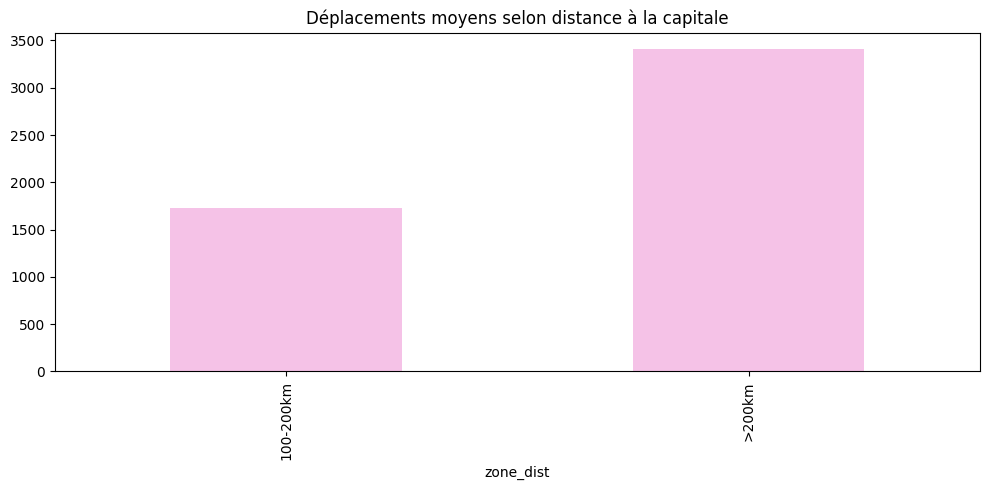

In [22]:
# 56-57. Corrélation distance ↔ taille + graphique
corr = df_geo[['dist_capitale', 'figure']].corr().iloc[0,1]
print(f"Corrélation distance ↔ déplacés : r = {corr:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
moy_zone = df_geo.groupby('zone_dist', observed=True)['figure'].mean()
moy_zone.plot(kind='bar', ax=ax, color='#f5c2e7')
ax.set_title('Déplacements moyens selon distance à la capitale')
plt.tight_layout()
save_current_fig('07_deplacements_moyen_par_distance_capital.png')
plt.show()

Taux de croissance moyen : 36.92%/mois

Équation tendance : y = -1133.5x + 13124.9
R²              : 0.147
Figure exportée : figures_tp02/08_tendance_mensuelle_regression.png


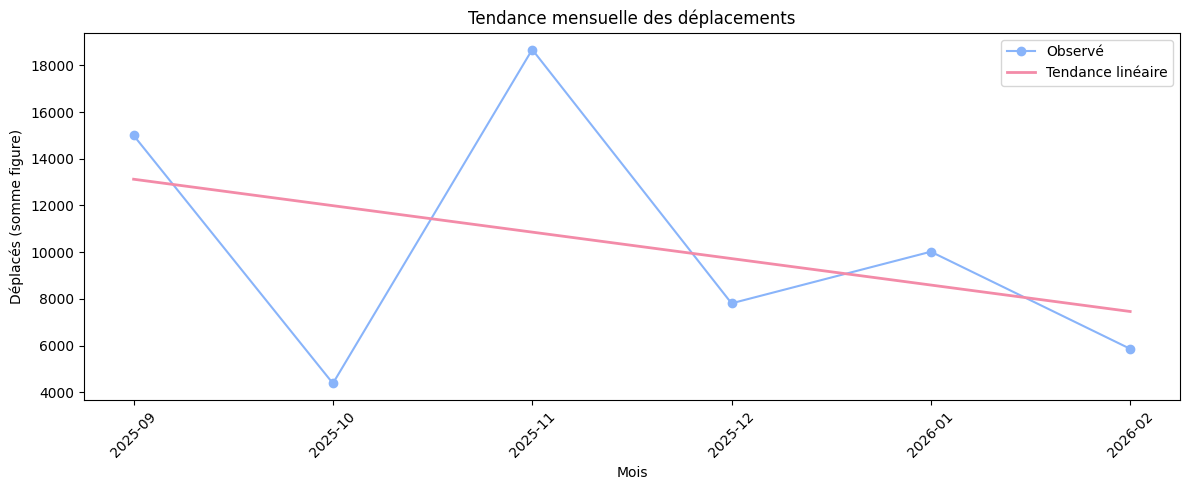


→ Prévision mois prochain : 6,324 déplacés


In [23]:
# 58-60. Taux de croissance + régression linéaire

# 58. Taux de croissance mensuel
croissance = deplac_par_mois.pct_change() * 100
print(f"Taux de croissance moyen : {croissance.mean():.2f}%/mois")

# 59-60. Régression linéaire avec np.polyfit
x = np.arange(len(deplac_par_mois))
y = deplac_par_mois.values

coeffs = np.polyfit(x, y, 1)
slope, intercept = coeffs

y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

print(f"\nÉquation tendance : y = {slope:.1f}x + {intercept:.1f}")
print(f"R²              : {r2:.3f}")

# Graphique de tendance (consigne 59)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(deplac_par_mois.index.astype(str), y, marker='o', color='#89b4fa', label='Observé')
ax.plot(deplac_par_mois.index.astype(str), y_pred, color='#f38ba8', linewidth=2, label='Tendance linéaire')
ax.set_title('Tendance mensuelle des déplacements')
ax.set_xlabel('Mois')
ax.set_ylabel('Déplacés (somme figure)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
save_current_fig('08_tendance_mensuelle_regression.png')
plt.show()

# 61. Prévision mois prochain
n_next    = len(deplac_par_mois)
prevision = slope * n_next + intercept
print(f"\n→ Prévision mois prochain : {prevision:,.0f} déplacés")

In [24]:
# 62. Export Excel multi-feuilles
with pd.ExcelWriter('Rapport_Deplacements.xlsx', engine='openpyxl') as writer:

    # Feuille Résumé
    resume_df = pd.DataFrame({
        'Métrique': ['Total événements', 'Total déplacés', 'Médiane/evt', 'Hotspots'],
        'Valeur'  : [len(df_geo), df_geo['figure'].sum(), mediane, len(hotspots)]
    })
    resume_df.to_excel(writer, sheet_name='Résumé', index=False)

    # Feuille Par_Region
    resume_region.to_excel(writer, sheet_name='Par_Region')

    # Feuille Hotspots
    hotspots.to_excel(writer, sheet_name='Hotspots')

    # Feuille Chronologie
    df_geo.sort_values('displacement_date').\
        to_excel(writer, sheet_name='Chronologie', index=False)

print("✓ Rapport_Deplacements.xlsx créé (4 feuilles)")

# 63. Export CSV hotspots pour SIG
hotspots.reset_index().to_csv('hotspots_SIG.csv', index=False)
print("✓ hotspots_SIG.csv exporté")

✓ Rapport_Deplacements.xlsx créé (4 feuilles)
✓ hotspots_SIG.csv exporté


In [25]:
# 64. Rapport Markdown
rapport_md = f"""
# 📋 Rapport : Déplacements de population — Burkina Faso

## Ampleur de la crise
- **{len(df_geo):,}** événements de déplacement recensés
- **{df_geo['figure'].sum():,}** personnes déplacées au total
- Médiane par événement : **{mediane:,.0f}** personnes
- Déplacements massifs (>P90) : **{len(massifs)}** événements

## Régions prioritaires
{resume_region.head(3).to_markdown()}

## Tendances temporelles
- Taux de croissance moyen : **{croissance.mean():.2f}%/mois**
- Pic enregistré : **{daily.max():,}** déplacés (journée)
- Prévision prochain mois : **{prevision:,.0f}** déplacés

## Recommandations
1. Renforcer la présence humanitaire dans la région Sahel (1er foyer)
2. Surveillance accrue en période Août–Septembre (pics saisonniers)
3. Prioriser les hotspots identifiés pour les interventions terrain
"""

with open('rapport_deplacements.md', 'w') as f:
    f.write(rapport_md)

print("✓ rapport_deplacements.md créé")
print("\n--- Aperçu ---")
print(rapport_md)

✓ rapport_deplacements.md créé

--- Aperçu ---

# 📋 Rapport : Déplacements de population — Burkina Faso

## Ampleur de la crise
- **25** événements de déplacement recensés
- **61,746** personnes déplacées au total
- Médiane par événement : **1,536** personnes
- Déplacements massifs (>P90) : **3** événements

## Régions prioritaires
| region            |   nb_evenements |   total_deplaces |   moyenne_par_evt |   min_deplaces |   max_deplaces |
|:------------------|----------------:|-----------------:|------------------:|---------------:|---------------:|
| Boucle du Mouhoun |              10 |            36783 |            3678.3 |           1349 |           9341 |
| Nord              |               9 |            17695 |            1966.1 |            211 |           3894 |
| Est               |               5 |             5898 |            1179.6 |            131 |           2868 |

## Tendances temporelles
- Taux de croissance moyen : **36.92%/mois**
- Pic enregistré : **18,682** 